# Chapter 3 Figures

## Kernel-Weight Method — Effective per-point weight diagnostic

Reproduces, for a single energy bin, the **effective per-point weight** that the
kernel-weight Monte-Carlo pass (Pass 2) assigns to every EXFOR data point:

$$w_{\mathrm{pp},i} = \omega_{g,i}\;g_{\mathrm{Kish},j}$$

where $\omega_{g,i}$ is the CDF-based **overlap weight** of the point's dataset to
the bin (Eq. overlap_weights) and $g_{\mathrm{Kish},j}=1/[1+(n_j-1)\rho_j]$ is the
study-level **GLS-ESS (Kish) factor** (Eq. kish_weight), with
$\rho_j=\sigma_{\mathrm{sys}}^2/(\sigma_{\mathrm{sys}}^2+\bar\sigma_{\mathrm{stat}}^2)$.

This mirrors the pipeline exactly (`exfor_to_endf_sampling_v2.py` → `run_mc_with_kernel_weights`
→ `_run_one_kw_sample`, `exfor_utils.py:2189-2231`), evaluated on the **nominal**
(unperturbed) data. To stay in sync it calls the pipeline's own functions:
`build_exfor_cache_from_objects` (applies the **uncertainty manifest** → per-point
`error_stat`/`error_sys`), `build_union_energy_grid`, `compute_energy_bins_with_tof_resolution`,
`compute_overlap_weight`, `get_tof_parameters`/`compute_sigma_E`.

Visual encoding:
- **Marker shape** = experiment
- **Color** = effective per-point weight $w_{\mathrm{pp}}$ (continuous colormap + colorbar)
- **Red edge** = core dataset (highest overlap weight per experiment); error bars shown for core points only

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

# Ensure the kika repo root is importable (so `kika` and `scripts` resolve).
# Override with KIKA_REPO_ROOT when running on a different machine.
REPO_ROOT = Path(os.environ.get("KIKA_REPO_ROOT", "/home/MONLEON-JUAN/kika"))
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from kika.exfor import read_all_exfor

# --- Pipeline functions (single source of truth — no re-implementation) ----- #
# Using the pipeline's own helpers guarantees the figure stays equivalent to
# the production run even if the weighting internals change.
from scripts.exfor_utils import (
    build_exfor_cache_from_objects,   # applies the uncertainty manifest -> error_stat / error_sys
    build_union_energy_grid,
    compute_energy_bins_with_tof_resolution,
    compute_overlap_weight,
)
from scripts.tof_parameters import (
    load_tof_parameters_file,
    get_tof_parameters,
    compute_sigma_E,
)
from scripts.uncertainty_manifest import load_manifest, _MANIFEST_PATH

# ── Config — MIRRORS exfor_to_endf_sampling_v2.py (keep values in sync) ────────
# Data source (exfor_to_endf_sampling_v2.py:186-205). Defaults are the /share_snc
# paths the pipeline uses on this host; override via env vars to run elsewhere.
DB_PATH           = os.environ.get("KIKA_X4PRO_DB_PATH",
                                   "/share_snc/snc/JuanMonleon/EXFOR/x4_iron_angular.db")          # cfg:188
SUPPLEMENTARY_JSON = os.environ.get("KIKA_SUPPLEMENTARY_JSON",
                                   "/share_snc/snc/JuanMonleon/EXFOR/data_v1/27673002.json")       # cfg:197
TOF_FILE          = Path(os.environ.get("KIKA_TOF_PARAMETERS_FILE",
                                   "/share_snc/snc/JuanMonleon/EXFOR/exfor_tof_parameters.json"))  # cfg:190

TARGET_ZAIDS      = [26056, 26000]   # Fe-56 + natural iron       (cfg:194)
TARGET_PROJECTILE = "N"              #                            (cfg:195)
MT_NUMBER         = 2               # elastic                    (cfg:203)
ENERGY_MIN, ENERGY_MAX = 0.847, 4.0  #                           (cfg:201-202)

# Datasets excluded from the cache (cfg:264):
#   32246002  Tostkii 1957;  400750022  Morozov 1972 ptr 2 (SPA-fitted double-count)
EXCLUDE_EXPERIMENTS = ["32246002", "400750022"]

# Union energy grid — Kinney below 2.5 MeV, Pirovano above (cfg:320-323).
UNION_GRID_SUBENTRIES = [
    ("10571002", 0.847, 2.5),   # Kinney
    ("23365005", 2.5, 4.0),     # Pirovano   (was Smith 10886002 in the old figure)
]

# TOF energy resolution (cfg:338-339)
DELTA_T_NS   = 5.0
FLIGHT_PATH_M = 27.037

# Kernel-weight / GLS-ESS weighting (cfg:260-306, 335)
KW_MC_MIN_WEIGHT        = 1e-3    # overlap weight threshold              (cfg:335)
NORM_SYSTEMATIC_SIGMA   = 0.05    # fallback per-experiment sigma_sys     (cfg:261)
MIN_RELATIVE_UNCERTAINTY = 1e-4   # rho-consistency floor on rel stat unc (cfg:265/280)
NORMALIZE_BY_N_POINTS   = True    # study-level GLS-ESS weighting on      (cfg:304)
BAND_AWARE_ESS          = False   # per-band Kish counts                  (cfg:305)
MAX_EXP_WEIGHT_FRAC_BIN = 0.8     # per-experiment WLS cap (diagnostic)   (cfg:306)

# Plotting
MARKERS = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', '<', '>', 'p', 'h']
CMAP = plt.cm.plasma

# Manuscript figure style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

# The uncertainty manifest is mandatory for the manifest-aware weights. Fail
# early with a clear message if it is not reachable on this machine.
_m = load_manifest()
print(f"Uncertainty manifest loaded from: {_MANIFEST_PATH}")
print(f"  ({len(_m.get('datasets', _m))} entries)")

Uncertainty manifest loaded from: /share_snc/snc/JuanMonleon/EXFOR/uncertainty_manifest.yaml
  (82 entries)


## 1. Load EXFOR data, apply the uncertainty manifest, and load TOF parameters

`build_exfor_cache_from_objects` is the pipeline's cache-build boundary: it applies
the uncertainty manifest to every dataset, splitting each point's uncertainty into
`error_stat` (per-point uncorrelated) and `error_sys` (per-point correlated systematic).
These are what the kernel-weight pass uses for $\rho_j$ and the per-point fit weights —
the figure must use the same split, not the raw EXFOR total.

In [2]:
# Load EXFOR angular distribution data exactly as the pipeline does
# (exfor_to_endf_sampling_v2.py:1853-1887): read_all_exfor -> build_exfor_cache_from_objects.
exfor_dict = read_all_exfor(
    source="database",
    db_path=DB_PATH,
    supplementary_json_files=[SUPPLEMENTARY_JSON],
    group_by_energy=False,
    target_zaid=TARGET_ZAIDS,
    projectile=TARGET_PROJECTILE,
    mt=MT_NUMBER,
)
exfor_objects = list(exfor_dict.values())
print(f"Loaded {len(exfor_objects)} EXFOR datasets")

# Build the manifest-aware cache. cache_df columns: angle, dsig, error_stat, error_sys.
# meta carries: entry, subentry, angle_frame, citation, sigma_sys_relative, ...
exfor_cache, sorted_energies = build_exfor_cache_from_objects(
    exfor_objects,
    exclude_experiments=EXCLUDE_EXPERIMENTS,
)
print(f"Cache: {len(sorted_energies)} unique energies "
      f"[{sorted_energies[0]:.4f}, {sorted_energies[-1]:.4f}] MeV")

# Label lookup keyed by study id = "entry.subentry" (matches the weight code below).
label_map = {f"{obj.entry}.{obj.subentry}": obj.label for obj in exfor_objects}

# TOF parameters cache (per-experiment flight path + time resolution).
tof_params_cache = load_tof_parameters_file(str(TOF_FILE))
print(f"TOF params loaded for {len(tof_params_cache)} subentries")

# Show loaded datasets + manifest flags for verification.
print("\nDatasets loaded:")
for obj in sorted(exfor_objects, key=lambda o: o.label):
    flag = getattr(obj, 'uncertainty_manifest_flag', 'default')
    e_range = obj.energies(unit="MeV")
    print(f"  {obj.entry}.{obj.subentry:8s}  {obj.label:30s}  "
          f"n_E={len(e_range):5d}  E=[{min(e_range):.4f}, {max(e_range):.4f}] MeV  "
          f"[manifest:{flag}]")

Loaded 120 EXFOR datasets
  [uncertainty_manifest] 10384016 (default→total): σ_sys capped at σ_total on 2/17 rows; σ_stat floored at 1% of |y| on 1/17 rows.
  [uncertainty_manifest] 10556006 (default→total): σ_sys capped at σ_total on 14/14 rows; σ_stat floored at 1% of |y| on 8/14 rows.
  [uncertainty_manifest] 10571002 (manifest): σ_sys capped at σ_total on 350/16008 rows; σ_stat floored at 1% of |y| on 190/16008 rows.
  [uncertainty_manifest] 10633008 (default→total): σ_sys capped at σ_total on 14/29 rows; σ_stat floored at 1% of |y| on 9/29 rows.
  [uncertainty_manifest] 10886002 (manifest): σ_sys capped at σ_total on 20/490 rows; σ_stat floored at 1% of |y| on 13/490 rows.
  [uncertainty_manifest] 11220013 (default→total): σ_sys capped at σ_total on 9/30 rows; σ_stat floored at 1% of |y| on 4/30 rows.
  [uncertainty_manifest] 11316003 (default→total): σ_sys capped at σ_total on 2/55 rows; σ_stat floored at 1% of |y| on 2/55 rows.
  [uncertainty_manifest] 11396011 (default→total): 

## 2. Build the union energy grid and bin boundaries

Calls the pipeline functions directly (`build_union_energy_grid` →
`compute_energy_bins_with_tof_resolution`) so the grid and bin boundaries are
identical to a production run.

In [3]:
# Union grid (in eV) from the configured subentries, then TOF-resolution bins.
# (exfor_to_endf_sampling_v2.py:2511-2529)
grid_energies_ev = build_union_energy_grid(
    exfor_cache=exfor_cache,
    subentries=UNION_GRID_SUBENTRIES,
    energy_min_mev=ENERGY_MIN,
    energy_max_mev=ENERGY_MAX,
)
print(f"Union grid: {len(grid_energies_ev)} points "
      f"[{grid_energies_ev[0]/1e6:.4f}, {grid_energies_ev[-1]/1e6:.4f}] MeV")

energy_bins = compute_energy_bins_with_tof_resolution(
    energies_ev=grid_energies_ev,
    energy_min_mev=ENERGY_MIN,
    energy_max_mev=ENERGY_MAX,
    delta_t_ns=DELTA_T_NS,
    flight_path_m=FLIGHT_PATH_M,
    reference_grid_ev=grid_energies_ev,
)
print(f"Energy bins: {len(energy_bins)}")
for b in [energy_bins[0], energy_bins[1], energy_bins[len(energy_bins) // 2], energy_bins[-1]]:
    print(f"  [{b.index:4d}] E={b.energy_mev:.4f} MeV  "
          f"bin=[{b.bin_lower_mev:.4f}, {b.bin_upper_mev:.4f}]  "
          f"width={1e3*(b.bin_upper_mev - b.bin_lower_mev):.2f} keV")

Union grid: 1738 points [0.8470, 4.0000] MeV
Energy bins: 1738
  [   0] E=0.8470 MeV  bin=[0.8465, 0.8475]  width=1.00 keV
  [   1] E=0.8480 MeV  bin=[0.8475, 0.8485]  width=1.00 keV
  [ 869] E=1.7160 MeV  bin=[1.7155, 1.7165]  width=1.00 keV
  [1737] E=4.0000 MeV  bin=[3.9964, 4.0036]  width=7.20 keV


## 3. Effective per-point weights (kernel-weight MC pass)

`compute_kw_weights_for_bin` reproduces the per-point weight that
`_run_one_kw_sample` builds for the fit (`exfor_utils.py:2189-2231`), evaluated on
**nominal** data (no perturbation, no degree sampling). For every dataset (one
`entry.subentry` at one energy) overlapping the bin with overlap weight
$\omega_g \ge$ `KW_MC_MIN_WEIGHT`:

1. **Overlap weight** $\omega_g$ from the dataset's TOF resolution
   (`compute_overlap_weight`, per-experiment `sigma_E`).
2. **Core dataset per study** = the overlapping `entry.subentry` cell with the
   largest $\omega_g$; its angular point count is $n_j$ (the Kish count).
3. **Kish factor** $g_j = 1/[1+(n_j-1)\rho_j]$ with
   $\rho_j = \sigma_{\mathrm{sys}}^2/(\sigma_{\mathrm{sys}}^2 + \bar\sigma_{\mathrm{stat}}^2)$,
   where $\sigma_{\mathrm{sys}}$ is the cell's manifest systematic
   (`error_sys/|dsig|`, falling back to `NORM_SYSTEMATIC_SIGMA`) and
   $\bar\sigma_{\mathrm{stat}}$ is the RMS relative `error_stat` (floored at
   `MIN_RELATIVE_UNCERTAINTY`).
4. **Effective per-point weight** $w_{\mathrm{pp}} = \omega_g\,g_j$.

The per-experiment WLS cap (`MAX_EXP_WEIGHT_FRAC_BIN`) is a downstream safety step
that rescales $w_{\mathrm{pp}}/\sigma^2$; it is reported in the table but not folded
into the plotted $w_{\mathrm{pp}}$, matching the figure's definition.

In [4]:
def compute_kw_weights_for_bin(target_energy_mev):
    """Nominal effective per-point weights for the bin nearest target_energy_mev.

    Mirrors _run_one_kw_sample (exfor_utils.py:2189-2231), non-band-aware,
    evaluated on unperturbed data: error_stat plays the role of pert['unc'],
    dsig of pert['value']. Returns one record per (entry.subentry, energy) cell.
    """
    bin_info = min(energy_bins, key=lambda b: abs(b.energy_mev - target_energy_mev))
    bin_lo, bin_hi = bin_info.bin_lower_mev, bin_info.bin_upper_mev

    # Step A: collect every dataset whose overlap weight to this bin >= threshold.
    cells = []
    for energy_mev in sorted_energies:
        for cache_df, meta in exfor_cache.get(energy_mev, []):
            entry, subentry = meta['entry'], meta['subentry']
            sid = f"{entry}{subentry}"  # naive form — matches precompute_overlap_weights()
            tof = get_tof_parameters(sid, tof_params_cache, FLIGHT_PATH_M, DELTA_T_NS)
            sigma_E = compute_sigma_E(energy_mev, tof)
            w = compute_overlap_weight(energy_mev, sigma_E, bin_lo, bin_hi)
            if w < KW_MC_MIN_WEIGHT:
                continue
            cells.append({
                'study_id': f"{entry}.{subentry}",
                'energy_mev': energy_mev,
                'w': float(w), 'sigma_E': float(sigma_E),
                'frame': meta.get('angle_frame', 'CM'),
                'angle': cache_df['angle'].to_numpy(float),
                'dsig': cache_df['dsig'].to_numpy(float),
                'error_stat': cache_df['error_stat'].to_numpy(float),
                'error_sys': cache_df['error_sys'].to_numpy(float),
                'n_points': len(cache_df),
            })

    # Step B: core cell per study = highest overlap weight -> n_study (Kish count).
    study_core = {}  # study_id -> (n_points, w)
    for c in cells:
        sid = c['study_id']
        if sid not in study_core or c['w'] > study_core[sid][1]:
            study_core[sid] = (c['n_points'], c['w'])

    # Step C: per cell, rho -> Kish g -> effective per-point weight w_pp = w * g.
    for c in cells:
        n_study = study_core[c['study_id']][0]
        val_safe = np.maximum(np.abs(c['dsig']), 1e-30)
        rel = c['error_stat'] / val_safe
        finite = np.isfinite(rel)
        rel_unc = float(np.sqrt(np.nanmean(rel[finite] ** 2))) if finite.any() else 0.0
        if not np.isfinite(rel_unc) or rel_unc <= 0:
            rel_unc = MIN_RELATIVE_UNCERTAINTY
        rel_unc = max(rel_unc, MIN_RELATIVE_UNCERTAINTY)
        # Manifest systematic (relative) — constant within a cell, take first point.
        sys_rel = np.abs(c['error_sys']) / val_safe
        ex_sigma_sys = float(sys_rel[0]) if sys_rel.size else 0.0
        sigma_eff = ex_sigma_sys if ex_sigma_sys > 0 else NORM_SYSTEMATIC_SIGMA
        rho = sigma_eff ** 2 / (sigma_eff ** 2 + rel_unc ** 2)
        g = 1.0 / (1.0 + max(n_study - 1, 0) * rho)
        c.update(n_study=n_study, rel_unc=rel_unc, sigma_sys=ex_sigma_sys,
                 rho=rho, g_kish=g, w_pp=c['w'] * g,
                 is_core=(c['w'] == study_core[c['study_id']][1]))

    return {
        'target': target_energy_mev, 'bin_info': bin_info,
        'bin_energy': bin_info.energy_mev, 'bin_lo': bin_lo, 'bin_hi': bin_hi,
        'cells': cells, 'exp_ids': sorted({c['study_id'] for c in cells}),
    }


def wls_fractions(cells, exp_ids):
    """Per-experiment WLS weight fraction, sum(w_pp / sigma_stat^2) (diagnostic).
    sigma_stat floored at MIN_RELATIVE_UNCERTAINTY*|dsig| to mirror the pipeline's
    post-floor uncertainties used by the per-experiment cap."""
    per = defaultdict(float)
    tot = 0.0
    for c in cells:
        val_safe = np.maximum(np.abs(c['dsig']), 1e-30)
        sigma = np.maximum(np.maximum(c['error_stat'], MIN_RELATIVE_UNCERTAINTY * val_safe), 1e-30)
        s = float(np.nansum(c['w_pp'] / sigma ** 2))
        per[c['study_id']] += s
        tot += s
    return {eid: (per[eid] / tot if tot > 0 else 0.0) for eid in exp_ids}


# ── Diagnostic table over several target energies ──
TARGET_ENERGIES = [0.85, 1.0, 1.30, 1.5, 1.8, 2.15, 2.5, 3.5]

for tE in TARGET_ENERGIES:
    diag = compute_kw_weights_for_bin(tE)
    cells, exp_ids = diag['cells'], diag['exp_ids']
    fr = wls_fractions(cells, exp_ids)
    be, lo, hi = diag['bin_energy'], diag['bin_lo'], diag['bin_hi']

    print(f"\n{'='*132}")
    print(f"E_target={tE:.2f} MeV -> grid E={be:.4f}, bin=[{lo:.4f}, {hi:.4f}], "
          f"width={1e3*(hi-lo):.2f} keV, n_cells={len(cells)}, n_exp={len(exp_ids)}")
    print(f"{'='*132}")
    print(f"{'Experiment':<28s} | {'n_E':>3s} | {'n_core':>6s} | {'sigE_k':>7s} | "
          f"{'overlap':>8s} | {'sys%':>6s} | {'stat%':>6s} | {'rho':>5s} | "
          f"{'g_Kish':>7s} | {'w_pp':>9s} | {'WLS%':>6s}")
    print(f"{'-'*28}-+-{'-'*3}-+-{'-'*6}-+-{'-'*7}-+-{'-'*8}-+-{'-'*6}-+-{'-'*6}-+-"
          f"{'-'*5}-+-{'-'*7}-+-{'-'*9}-+-{'-'*6}")
    for eid in sorted(exp_ids, key=lambda e: -fr[e]):
        ec = [c for c in cells if c['study_id'] == eid]
        core = max(ec, key=lambda c: c['w'])
        label = label_map.get(eid, eid)[:28]
        cap = " *cap" if fr[eid] > MAX_EXP_WEIGHT_FRAC_BIN else ""
        print(f"{label:<28s} | {len(ec):3d} | {core['n_study']:6d} | "
              f"{core['sigma_E']*1e3:6.1f}k | {core['w']:8.4f} | "
              f"{core['sigma_sys']*100:5.1f}% | {core['rel_unc']*100:5.1f}% | "
              f"{core['rho']:5.2f} | {core['g_kish']:7.4f} | {core['w_pp']:9.5f} | "
              f"{fr[eid]*100:5.1f}%{cap}")


E_target=0.85 MeV -> grid E=0.8500, bin=[0.8495, 0.8505], width=1.00 keV, n_cells=327, n_exp=12
Experiment                   | n_E | n_core |  sigE_k |  overlap |   sys% |  stat% |   rho |  g_Kish |      w_pp |   WLS%
-----------------------------+-----+--------+---------+----------+--------+--------+-------+---------+-----------+-------
Perey (1991)                 |  62 |      6 |    4.0k |   0.0992 |   5.0% |   0.0% |  1.00 |  0.1667 |   0.01653 |  63.9%
Cierjacks (1978)             | 188 |      4 |    2.1k |   0.1899 |   7.0% |   0.0% |  1.00 |  0.2500 |   0.04748 |  34.3%
Cabe (1967)                  |   1 |     10 |    4.0k |   0.0456 |   5.0% |   0.0% |  1.00 |  0.1000 |   0.00456 |   1.7%
Kinney (1976)                |  26 |      8 |    4.3k |   0.0918 |   8.1% |   5.7% |  0.67 |  0.1768 |   0.01623 |   0.0%
Wells (1963)                 |   8 |      1 |    4.0k |   0.0879 |  24.0% |   3.0% |  0.98 |  1.0000 |   0.08793 |   0.0%
Wells (1963)                 |   7 |      1 |    

## 4. Figure — effective per-point weights $w_{\mathrm{pp}}$ at E = 1.30 MeV

This is `kernel-weight.png` in Chapter 3. Each point is colored by its effective
per-point weight $w_{\mathrm{pp}} = \omega_g\,g_{\mathrm{Kish}}$; marker shape encodes
the experiment; the **core** point of each experiment (highest overlap weight) is
drawn larger with a **red edge** and its statistical error bar.

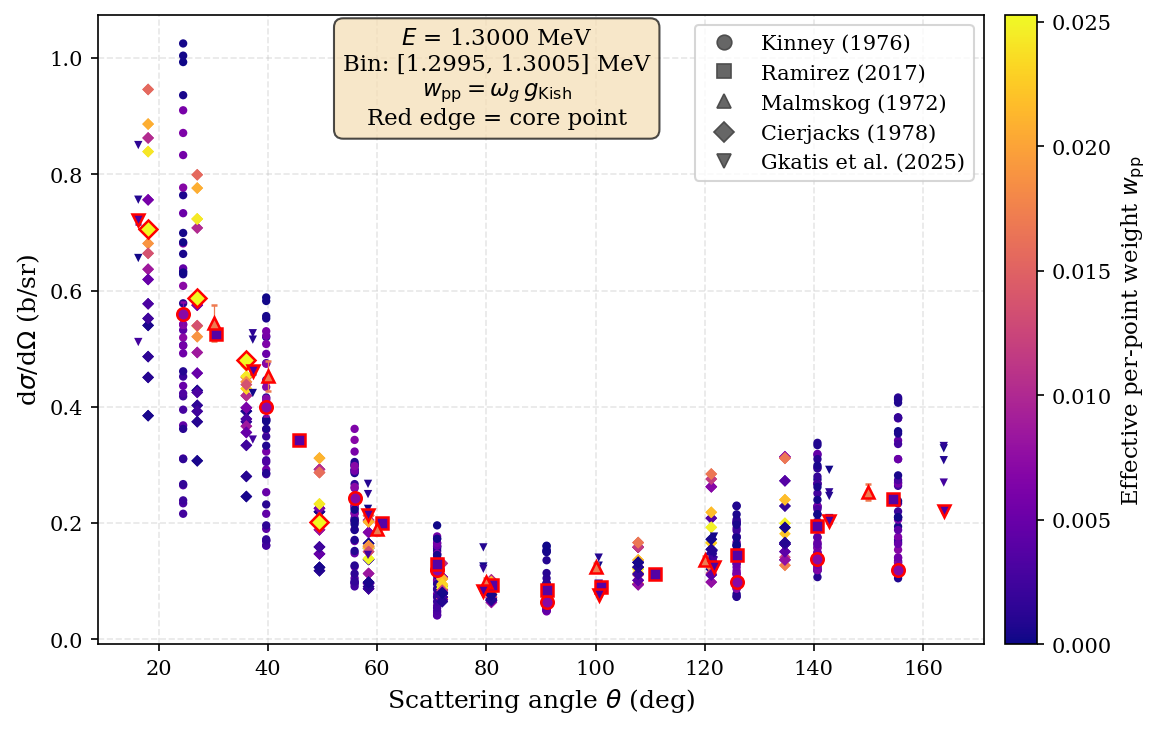

In [8]:
# Energy for the published figure. The Chapter 3 caption (Chapter_3.tex:827) states
# E = 1.30 MeV; change this single constant to regenerate at another energy.
PLOT_ENERGY_MEV = 1.30

diag = compute_kw_weights_for_bin(PLOT_ENERGY_MEV)
cells, exp_ids = diag['cells'], diag['exp_ids']
be, lo, hi = diag['bin_energy'], diag['bin_lo'], diag['bin_hi']

fig, ax = plt.subplots(figsize=(8, 5))

all_wpp = [c['w_pp'] for c in cells]
w_norm = mcolors.Normalize(vmin=0, vmax=max(all_wpp))
sm = cm.ScalarMappable(cmap=CMAP, norm=w_norm)
sm.set_array([])

exp_marker = {eid: MARKERS[i % len(MARKERS)] for i, eid in enumerate(exp_ids)}

for eid in exp_ids:
    marker = exp_marker[eid]
    ec = [c for c in cells if c['study_id'] == eid]

    # Non-core cells: small markers, no edge, colored by w_pp.
    non_core = [c for c in ec if not c['is_core']]
    if non_core:
        angles = np.concatenate([c['angle'] for c in non_core])
        values = np.concatenate([c['dsig'] for c in non_core])
        colors = np.concatenate([np.full(len(c['angle']), c['w_pp']) for c in non_core])
        ax.scatter(angles, values, c=CMAP(w_norm(colors)), marker=marker, s=16,
                   edgecolors="none", zorder=2)

    # Core cell: larger markers with RED edge + statistical error bars.
    for c in ec:
        if not c['is_core']:
            continue
        color = CMAP(w_norm(c['w_pp']))
        ax.errorbar(c['angle'], c['dsig'], yerr=c['error_stat'],
                    fmt=marker, color=color,
                    markeredgecolor="red", markeredgewidth=1.2, markersize=6.0,
                    capsize=1.5, capthick=0.6, elinewidth=0.6, ecolor=color,
                    zorder=4, label="_nolegend_")

cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"Effective per-point weight $w_{\mathrm{pp}}$", fontsize=11)

legend_handles = [
    Line2D([0], [0], marker=exp_marker[eid], color="none",
           markerfacecolor="0.4", markeredgecolor="0.3", markersize=7,
           markeredgewidth=0.8, label=label_map.get(eid, eid))
    for eid in exp_ids
]
ax.legend(handles=legend_handles, loc="upper right", frameon=True,
          fancybox=True, fontsize=10, ncol=1)

ax.set_xlabel(r"Scattering angle $\theta$ (deg)")
ax.set_ylabel(r"d$\sigma$/d$\Omega$ (b/sr)")

textstr = (f"$E$ = {be:.4f} MeV\n"
           f"Bin: [{lo:.4f}, {hi:.4f}] MeV\n"
           r"$w_{\mathrm{pp}} = \omega_g\,g_{\mathrm{Kish}}$" "\n"
           "Red edge = core point")
props = dict(boxstyle="round,pad=0.4", facecolor="wheat", alpha=0.7)
ax.text(0.45, 0.98, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment="top", horizontalalignment="center", bbox=props)

plt.tight_layout()
plt.show()
# Renders inline; save manually as kernel-weight.png (project convention).